- Supraglacial Lakes
    * Description: This dataset consists of the maximum extent of supraglacial hydrological activity during January 2017 and detailed 10,478 supraglacial features (10,223 lakes and 255 channels), with cumulative area 119.4 square km in total on the West Antarctic ice sheet and Antarctic Peninsula.
    * Original Data Source: https://zenodo.org/record/5642755
    * Reference: https://essd.copernicus.org/articles/14/209/2022/
    * OSC entry: https://opensciencedata.esa.int/products/supraglacial-lakes-west-4dantarctica/collection
    * License: CC-BY-4.0
    * Repo Folder: ./datasets/supraglacial_lakes

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [14]:
antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [15]:
# Read the subglacial lakes boundaries
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/supraglacial_lakes/WAIS_Jan_2017_Polygons.parquet'


gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)
gdf

,POLY_AREA,CENTROID_X,CENTROID_Y,Area,Shape_Leng,Shape_Area,Bedrock,Coast,GL_ON_IS,Location,...,PolsbyPopp,Fractal,Reock,Schwartzbe,LW_Ratio,Feature_Cl,Elevation,Slope,Speed,geometry
0,2250.000000,-1.122141e+06,-1.179198e+06,2298.467416,240.00000,2250.000000,439.236720,16041.380634,0.000000,Grounded Ice,...,0.490874,1.408355,0.506300,0.700624,0.857143,Lake,360,1.884210,61.69920,"POLYGON ((-1122127.5 -1179172.5, -1122127.5 -1..."
1,25200.000000,-1.122477e+06,-1.178988e+06,25742.726268,2160.00000,25200.000000,415.759238,16085.345499,0.000000,Grounded Ice,...,0.067874,1.319976,0.052796,0.260526,0.114516,Channel,360,1.884210,60.73470,"MULTIPOLYGON (((-1122607.5 -1178917.5, -112265..."
2,675.000000,-1.122930e+06,-1.178760e+06,689.534115,120.00000,675.000000,740.341624,16507.511953,0.000000,Grounded Ice,...,0.589049,1.360778,0.381972,0.767495,0.333333,Lake,388,2.731610,39.97260,"POLYGON ((-1122907.5 -1178767.5, -1122952.5 -1..."
3,11250.000000,-1.123134e+06,-1.178679e+06,11492.233178,930.00000,11250.000000,770.661893,16537.853558,0.000000,Grounded Ice,...,0.163454,1.364722,0.112676,0.404295,0.186667,Lake,388,2.731610,46.55940,"POLYGON ((-1123267.5 -1178602.5, -1123267.5 -1..."
4,198.750411,-1.809312e+06,7.091160e+05,200.159238,59.81225,198.750411,14427.999008,134873.872142,418.393202,Ice Shelf,...,0.698132,1.293517,0.509294,0.835543,0.500000,Lake,37,0.121964,9.98336,"POLYGON ((-1809304.184 709123.549, -1809311.33..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10473,2025.000000,2.573867e+05,-7.738833e+05,2121.704652,240.00000,2025.000000,0.000000,496657.687060,0.000000,Grounded Ice,...,0.441786,1.389131,0.449199,0.664670,0.666667,Lake,502,7.215030,47.97920,"POLYGON ((257407.5 -773857.5, 257407.5 -773872..."
10474,450.000000,2.574525e+05,-7.738425e+05,471.491754,120.00000,450.000000,0.000000,496703.680279,0.000000,Grounded Ice,...,0.392699,1.276085,0.318310,0.626657,0.500000,Lake,502,7.215030,47.97920,"MULTIPOLYGON (((257452.5 -773842.5, 257452.5 -..."
10475,3375.000000,2.576260e+05,-7.736940e+05,3536.188110,480.00000,3375.000000,74.210787,496768.404299,0.000000,Grounded Ice,...,0.184078,1.315911,0.169014,0.429043,0.333333,Lake,471,7.997810,56.07010,"MULTIPOLYGON (((257587.5 -773752.5, 257587.5 -..."
10476,6750.000000,2.577890e+05,-7.736955e+05,7072.372180,630.00000,6750.000000,135.624326,496743.461225,0.000000,Grounded Ice,...,0.213714,1.367931,0.232910,0.462292,0.444444,Lake,471,7.997810,56.07010,"POLYGON ((257827.5 -773677.5, 257827.5 -773707..."


In [16]:
pad

244143.6

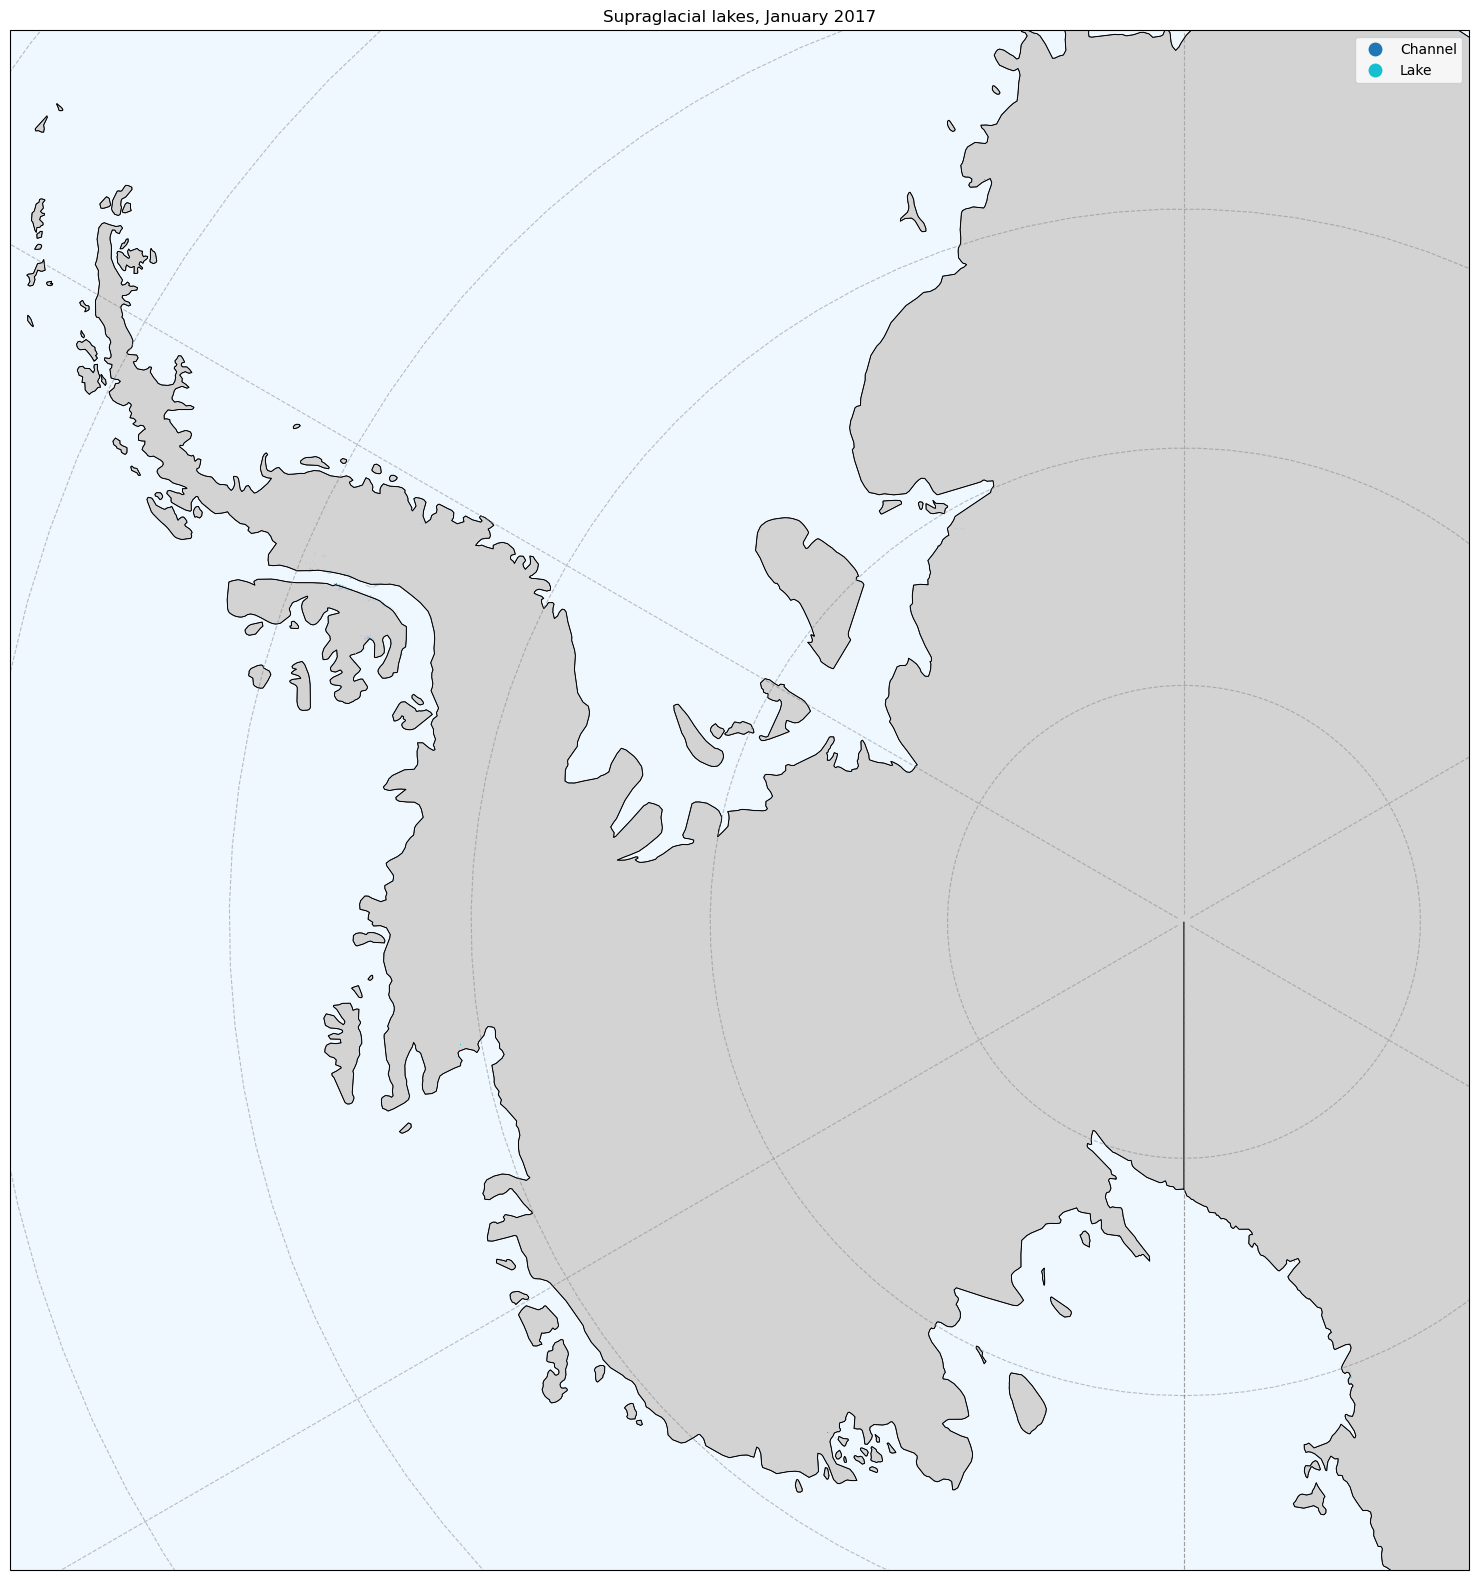

In [17]:
gdf_3031 = gdf.to_crs(epsg=3031)

fig, ax = plt.subplots(
    figsize=(20, 20),
    subplot_kw={"projection": antarctic_crs},
)

ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.4, zorder=1)
ax.coastlines(resolution="50m", color="black", linewidth=0.7, zorder=2)
ax.gridlines(draw_labels=False, color="gray", alpha=0.5, linestyle="--")

gdf_3031.plot(column="Feature_Cl", legend=True, ax=ax, zorder=3)

minx, miny, maxx, maxy = gdf_3031.total_bounds
pad = max(maxx - minx, maxy - miny) * 0.08
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=antarctic_crs)

ax.set_title("Supraglacial lakes, January 2017")
plt.show()